# Machine Learning Modell für die Erkennung von potentiell gefährlichen Asteroiden mithilfe der Nasa NeoWs API.

## Trainieren des Klassifikationsmodells

### Laden von Trainingsdaten aus der API und abspeichern als CSV

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

In [ ]:
NASA_API_KEY = ""
NEON_DB_URL = ""

In [ ]:
def fetch_historical_asteroid_data(start_date_str, weeks_to_fetch=4):
  asteroids = []

  # start_date_str in Zeitobjekt umwandeln
  current_start_date = datetime.strptime(start_date_str, "%Y-%m-%d")

  for i in range(weeks_to_fetch):
    current_end_date = current_start_date + timedelta(days=7)

    # start und Enddatum in String umwandeln
    start_str = current_start_date.strftime("%Y-%m-%d")
    end_str = current_end_date.strftime("%Y-%m-%d")

    print(f"Lade Daten von {start_str} bis {end_str}...")

    url = f"https://api.nasa.gov/neo/rest/v1/feed?start_date={start_str}&end_date={end_str}&api_key={NASA_API_KEY}"
    response = requests.get(url)

    if response.status_code == 200:
      json_data = response.json()
      neo_data = json_data.get('near_earth_objects', {})

      # --- DER FIX IST HIER ---
      # neo_data sieht so aus: {"2024-01-01": [ast1, ast2], "2024-01-02": [ast3, ast4], ...}
      # Wir müssen über jeden Tag iterieren und die Listen zusammenfügen
      for date_key, daily_asteroids_list in neo_data.items():
          asteroids.extend(daily_asteroids_list)
      # ------------------------

    else:
      print(f"Fehler bei {start_str}: Status {response.status_code}")
      # Bei Fehlern (z.B. Rate Limit) kurz warten und nicht gleich abbrechen,
      # manchmal fängt sich die API wieder.
      time.sleep(5)
      continue

    time.sleep(10)

    # Das nächste Startdatum ist das letzte Enddatum + 1 Tag
    current_start_date = current_end_date + timedelta(days=1)

  return asteroids



In [ ]:
raw_historical_data = fetch_historical_asteroid_data("2023-01-01", weeks_to_fetch=150)

print(f"\n Insgesamt {len(raw_historical_data)} Asteroiden geladen.")

Lade Daten von 2023-01-01 bis 2023-01-08...
Lade Daten von 2023-01-09 bis 2023-01-16...
Lade Daten von 2023-01-17 bis 2023-01-24...
Lade Daten von 2023-01-25 bis 2023-02-01...
Lade Daten von 2023-02-02 bis 2023-02-09...
Lade Daten von 2023-02-10 bis 2023-02-17...
Lade Daten von 2023-02-18 bis 2023-02-25...
Lade Daten von 2023-02-26 bis 2023-03-05...
Lade Daten von 2023-03-06 bis 2023-03-13...
Lade Daten von 2023-03-14 bis 2023-03-21...
Lade Daten von 2023-03-22 bis 2023-03-29...
Lade Daten von 2023-03-30 bis 2023-04-06...
Lade Daten von 2023-04-07 bis 2023-04-14...
Lade Daten von 2023-04-15 bis 2023-04-22...
Lade Daten von 2023-04-23 bis 2023-04-30...
Lade Daten von 2023-05-01 bis 2023-05-08...
Lade Daten von 2023-05-09 bis 2023-05-16...
Lade Daten von 2023-05-17 bis 2023-05-24...
Lade Daten von 2023-05-25 bis 2023-06-01...
Lade Daten von 2023-06-02 bis 2023-06-09...
Lade Daten von 2023-06-10 bis 2023-06-17...
Lade Daten von 2023-06-18 bis 2023-06-25...
Lade Daten von 2023-06-26 bis 20

In [ ]:
raw_historical_data[:1]

[{'links': {'self': 'http://api.nasa.gov/neo/rest/v1/neo/2453309?api_key=deM46Vp3uQdKbmLgWNS1xeDS2PDqbnTwjoDhg50z'},
  'id': '2453309',
  'neo_reference_id': '2453309',
  'name': '453309 (2008 VQ4)',
  'nasa_jpl_url': 'https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=2453309',
  'absolute_magnitude_h': 19.51,
  'estimated_diameter': {'kilometers': {'estimated_diameter_min': 0.3330849243,
    'estimated_diameter_max': 0.744800533},
   'meters': {'estimated_diameter_min': 333.0849242994,
    'estimated_diameter_max': 744.8005330139},
   'miles': {'estimated_diameter_min': 0.2069693125,
    'estimated_diameter_max': 0.462797452},
   'feet': {'estimated_diameter_min': 1092.7983430385,
    'estimated_diameter_max': 2443.5713807333}},
  'is_potentially_hazardous_asteroid': False,
  'close_approach_data': [{'close_approach_date': '2023-01-01',
    'close_approach_date_full': '2023-Jan-01 20:20',
    'epoch_date_close_approach': 1672604400000,
    'relative_velocity': {'kilometers_per_se

In [ ]:
# Abflachen der Daten, damit sie als CSV gespeichert werden können

rows = []

for ast in raw_historical_data:
  row = {
      'id': ast['id'],
      'name': ast['name'],
      'estimated_diameter_min_km': ast['estimated_diameter']['kilometers']['estimated_diameter_min'],
      'estimated_diameter_max_km': ast['estimated_diameter']['kilometers']['estimated_diameter_max'],
      'relative_velocity_kph': float(ast['close_approach_data'][0]['relative_velocity']['kilometers_per_hour']),
      'miss_distance_km': float(ast['close_approach_data'][0]['miss_distance']['kilometers']),
      'is_potentially_hazardous': ast['is_potentially_hazardous_asteroid'],
      'close_approach_date': ast['close_approach_data'][0]['close_approach_date'],
  }

  rows.append(row)


rows[:1]

[{'id': '2453309',
  'name': '453309 (2008 VQ4)',
  'estimated_diameter_min_km': 0.3330849243,
  'estimated_diameter_max_km': 0.744800533,
  'relative_velocity_kph': 20959.8207659374,
  'miss_distance_km': 39565961.76020504,
  'is_potentially_hazardous': False,
  'close_approach_date': '2023-01-01'}]

In [ ]:
df = pd.DataFrame(rows)

df.to_csv("asteroids.csv", index=False)

### Exploratory Data Analysis

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("asteroids.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6487 entries, 0 to 6486
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         6487 non-null   int64  
 1   name                       6487 non-null   object 
 2   estimated_diameter_min_km  6487 non-null   float64
 3   estimated_diameter_max_km  6487 non-null   float64
 4   relative_velocity_kph      6487 non-null   float64
 5   miss_distance_km           6487 non-null   float64
 6   is_potentially_hazardous   6487 non-null   bool   
 7   close_approach_date        6487 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 361.2+ KB


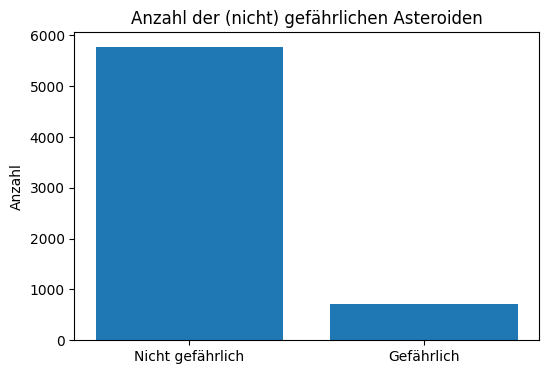

In [ ]:
# Wie viele Asteroiden sind (nicht) gefährlich
is_potentially_hazardous_count = df['is_potentially_hazardous'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Nicht gefährlich', 'Gefährlich'], is_potentially_hazardous_count)
plt.title('Anzahl der (nicht) gefährlichen Asteroiden')
plt.ylabel('Anzahl')
plt.show()

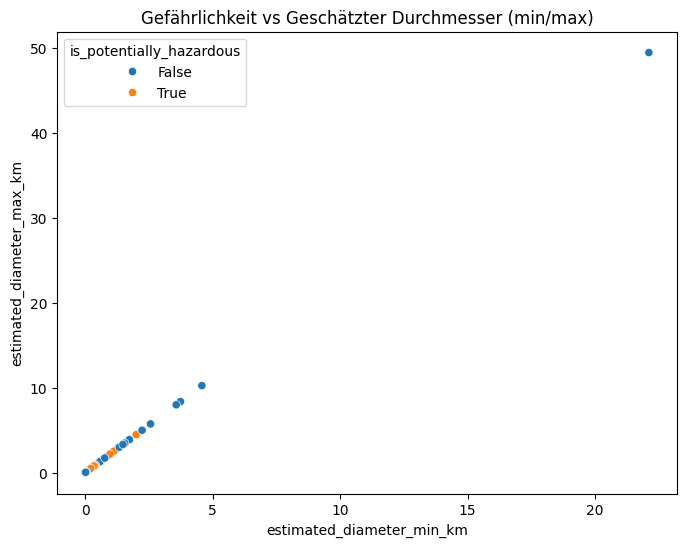

In [ ]:
# Gefahr vs. Durchmesser
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x='estimated_diameter_min_km',
                y='estimated_diameter_max_km',
                hue='is_potentially_hazardous')
plt.title("Gefährlichkeit vs Geschätzter Durchmesser (min/max)")
plt.show()

#df["estimated_diameter_max_km"] / df["estimated_diameter_min_km"]


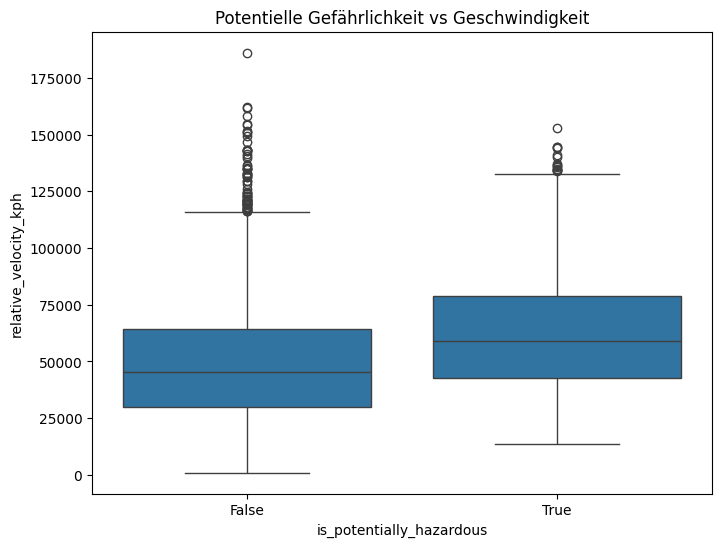

In [ ]:
# Gefahr vs Geschwindigkeit
plt.figure(figsize=(8,6))
sns.boxplot(data=df,
            x='is_potentially_hazardous',
            y='relative_velocity_kph')
plt.title("Potentielle Gefährlichkeit vs Geschwindigkeit")
plt.show()

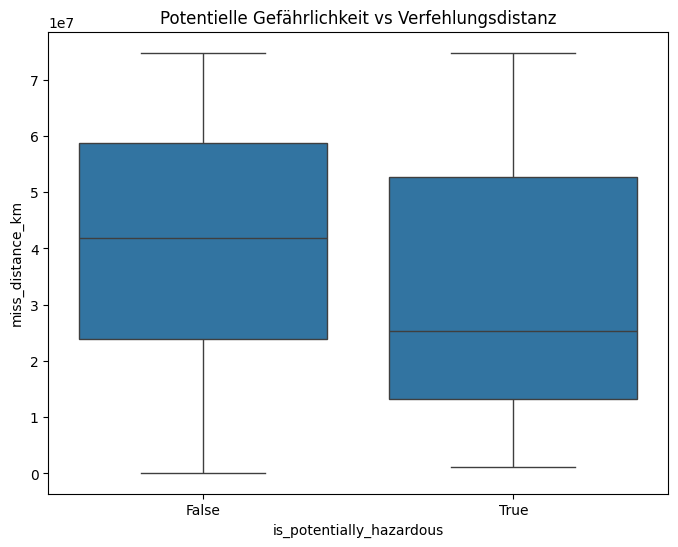

In [ ]:
# Gefahr vs miss distance
plt.figure(figsize=(8,6))
sns.boxplot(data=df,
            x='is_potentially_hazardous',
            y='miss_distance_km')
plt.title("Potentielle Gefährlichkeit vs Verfehlungsdistanz")
plt.show()

### Modell trainieren

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Wir isolieren die Spalten, die das Modell als "Hinweise" nutzen soll (Features)
# Wichtig: Wir werfen IDs, Namen und Daten raus, da sie keine physikalische Bedeutung für die Gefahr haben.
features = [
    'estimated_diameter_min_km',
    'estimated_diameter_max_km',
    'relative_velocity_kph',
    'miss_distance_km'
]
X = df[features]

# 2. Das ist unser Ziel (Target), das vorhergesagt werden soll (True/False)
y = df['is_potentially_hazardous']

# 3. Wir teilen die Daten auf: 80% zum Trainieren, 20% zum Testen
# random_state=42 sorgt dafür, dass das Ergebnis jedes Mal gleich ist, wenn du das Skript neu startest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Trainingsdaten: {len(X_train)} Asteroiden")
print(f"Testdaten: {len(X_test)} Asteroiden")

Trainingsdaten: 5189 Asteroiden
Testdaten: 1298 Asteroiden


              precision    recall  f1-score   support

       False       0.99      0.80      0.89      1137
        True       0.41      0.94      0.57       161

    accuracy                           0.82      1298
   macro avg       0.70      0.87      0.73      1298
weighted avg       0.92      0.82      0.85      1298



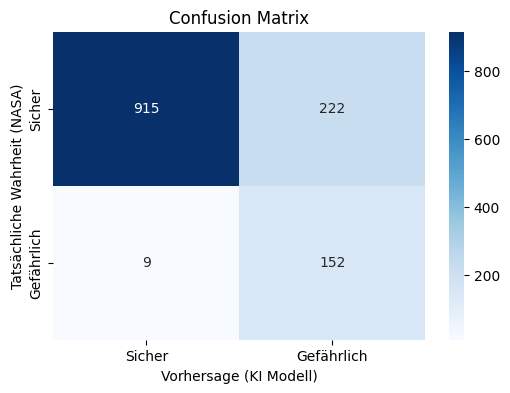

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Das Modell initialisieren
# class_weight='balanced' hilft extrem bei seltenen Ereignissen (wie gefährlichen Asteroiden)
# Wir zwingen das Modell, die seltene Klasse "True" noch stärker zu gewichten (z.B. 10x wichtiger)
# class_weight='balanced' war gut, aber oft nicht stark genug. Wir übergeben ein festes Dictionary:
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,            # Mehr Bäume (200 statt 100) für ein stabileres Ergebnis
    max_depth=10,                # Bäume dürfen nicht unendlich tief wachsen (verhindert Overfitting)
    min_samples_leaf=5,          # Ein "Blatt" am Ende eines Astes muss mind. 5 Beispiele haben
    class_weight={False: 1, True: 10}, # WICHTIG: "True" wird jetzt als 10x wichtiger angesehen!
    random_state=42
)

# Trainieren mit den Tuning-Parametern
rf_model_tuned.fit(X_train, y_train)
y_pred_tuned = rf_model_tuned.predict(X_test)

# Evaluieren
print(classification_report(y_test, y_pred_tuned))

# 5. Confusion Matrix (Wahrheitsmatrix) visuell darstellen
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sicher', 'Gefährlich'],
            yticklabels=['Sicher', 'Gefährlich'])
plt.ylabel('Tatsächliche Wahrheit (NASA)')
plt.xlabel('Vorhersage (KI Modell)')
plt.title('Confusion Matrix')
plt.show()




In [ ]:
import joblib

# Modell speichern
joblib.dump(rf_model_tuned, 'asteroid_danger_model.joblib')
print("Modell gespeichert! Bitte lade die Datei jetzt aus Colab herunter.")

Modell gespeichert! Bitte lade die Datei jetzt aus Colab herunter.
